# РОЗРАХУНКОВО-ГРАФIЧНА РОБОТА 
### «Порівняння алгоритмів ACO, PSO та GWO у задачі оптимізації логістичних маршрутів»

In [1]:
import pandas as pd
import numpy as np
import time
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## 1. Алгоритми оптимізації

### 1.1 ACO (Ant Colony Optimization) - мурашиний алгоритм 

$$
P_{ij,k}(t) =
\begin{cases}
\frac{[\tau_{ij}(t)]^{\alpha} [\eta_{ij}]^{\beta}}
{\sum\limits_{l \in J_{i,k}} [\tau_{il}(t)]^{\alpha} [\eta_{il}]^{\beta}}, & j \in J_{i,k} \\\\
0, & j \notin J_{i,k}
\end{cases}
$$

$$
\Delta \tau_{ij,k}(t) =
\begin{cases}
\frac{Q}{L_k(t)}, & (i,j) \in T_k(t) \\\\
0, & (i,j) \notin T_k(t)
\end{cases}
$$

$$
\tau_{ij}(t+1) = (1 - \rho)\tau_{ij}(t) + \Delta \tau_{ij}(t)
$$

In [2]:
def ant_algorithm(dist_matrix, iterations, ants, alpha=1.3, beta=6, rho=0.55, Q=150):

    n_cities = dist_matrix.shape[0]
    
    tau = np.ones((n_cities, n_cities))
    eta = np.zeros((n_cities, n_cities))

    for i in range(n_cities):
        for j in range(n_cities):
            if i != j:
                eta[i, j] = 1 / (dist_matrix[i, j] + 1e-10)

    best_path = None
    best_length = np.inf

    best_history = []
    best_path_history = []

    for _ in range(iterations):

        all_paths = []
        all_lengths = []

        for _ in range(ants):

            start = np.random.randint(n_cities)
            path = [start]
            visited = set(path)

            while len(path) < n_cities:

                current = path[-1]

                allowed = [j for j in range(n_cities) if j not in visited]

                probs = np.array([
                    (tau[current, j] ** alpha) * (eta[current, j] ** beta)
                    for j in allowed
                ])
                
                if probs.sum() == 0:
                    probs = np.ones(len(probs))

                probs = probs / probs.sum()

                next_city = np.random.choice(allowed, p=probs)

                path.append(next_city)
                visited.add(next_city)

            length = sum(dist_matrix[path[i], path[i+1]] for i in range(n_cities - 1))

            length += dist_matrix[path[-1], path[0]]

            all_paths.append(path)
            all_lengths.append(length)

            if length < best_length:
                best_length = length
                best_path = path.copy()

        delta_tau = np.zeros((n_cities, n_cities))

        for path, length in zip(all_paths, all_lengths):
            for i in range(n_cities):
                j = (i + 1) % n_cities
                delta_tau[path[i], path[j]] += Q / length

        tau = (1 - rho) * tau + delta_tau

        best_history.append(best_length)
        best_path_history.append(best_path.copy())

    return best_path, best_length, best_history, best_path_history

### 1.2 PSO (Particle Swarm Optimization) — алгоритм рою частинок.
#### $$ v_k = v_k + \alpha_1 (x_k^{best} - x_k) r_1 + \alpha_2 (x^* - x_k) r_2 $$
#### $$α_1, α_2 ∈ (0; 4)$$

In [3]:
def pso(F, dim, pop_size, generations):

    alpha1 = 1.5
    alpha2 = 1.5

    x_min, x_max = 0, 1
    v_min, v_max = -1, 1

    X = np.random.uniform(x_min, x_max, (pop_size, dim))
    V = np.random.uniform(v_min, v_max, (pop_size, dim))

    def decode(x):
        return np.argsort(x)

    X_best = X.copy()
    F_best = np.array([F(decode(x)) for x in X_best])

    best_idx = np.argmin(F_best)
    gbest = X_best[best_idx].copy()
    gbest_val = F_best[best_idx]

    history = []

    for _ in range(generations):

        for i in range(pop_size):

            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)

            V[i] = ( V[i] + alpha1 * r1 * (X_best[i] - X[i]) + alpha2 * r2 * (gbest - X[i]))

            X[i] = X[i] + V[i]

            X[i] = np.clip(X[i], 0, 1)

            route = decode(X[i])
            f = F(route)

            if f < F_best[i]:
                X_best[i] = X[i].copy()
                F_best[i] = f

        best_idx = np.argmin(F_best)

        if F_best[best_idx] < gbest_val:
            gbest = X_best[best_idx].copy()
            gbest_val = F_best[best_idx]

        history.append(gbest_val)

    return decode(gbest), gbest_val, history

### 1.3 GWO (Grey Wolf Optimizer) — алгоритм сірих вовків
#### $$ x_i^{new} = x_i + step \cdot \frac{GBest - x_i}{\|GBest - x_i\|} $$

In [4]:
def gwo(func, pop_size, generations, dim):

    wolves = np.random.rand(pop_size, dim)

    def decode(x):
        return np.argsort(x)

    fitness_value = np.array([func(decode(w)) for w in wolves])

    idx = np.argmin(fitness_value)
    alpha = wolves[idx].copy()
    alpha_score = fitness_value[idx]

    history = []
    population_history = []

    a = 2  
    for t in range(generations):

        A = 2 * a * np.random.rand(pop_size, dim) - a
        C = 2 * np.random.rand(pop_size, dim)

        for i in range(pop_size):

            D_alpha = abs(C[i] * alpha - wolves[i])
            X1 = alpha - A[i] * D_alpha

            wolves[i] = X1

            wolves[i] = np.clip(wolves[i], 0, 1)

        fitness_value = np.array([func(decode(w)) for w in wolves])

        idx = np.argmin(fitness_value)

        if fitness_value[idx] < alpha_score:
            alpha = wolves[idx].copy()
            alpha_score = fitness_value[idx]

        a = 2 - 2 * t / generations

        population_history.append(wolves.copy())
        history.append(alpha_score)

    return decode(alpha), alpha_score, history, population_history

## 2. Підготовка даних про міста для задачі оптимізації
### 2.1 Завантаження даних

In [5]:
df = pd.read_csv("worldcities.csv")

### 2.2 Вибір потрібних даних

In [6]:
ukraine_df = df[df["country"] == "Ukraine"]
ukraine_df = ukraine_df[["city", "lat", "lng"]]

ukraine_df = ukraine_df.rename(columns={
    "lat": "y",
    "lng": "x"
})

In [7]:
ukraine_df = ukraine_df.reset_index(drop=True)
print(ukraine_df.head())

      city        y        x
0     Kyiv  50.4500  30.5233
1  Kharkiv  49.9925  36.2311
2    Odesa  46.4920  30.7081
3   Dnipro  48.4675  35.0400
4  Donetsk  48.0028  37.8053


### 2.3 Перевірка на порожні значення

In [8]:
print("Кількість порожніх значень:")
print(ukraine_df.isnull().sum())

ukraine_df.to_csv("ukraine_cities.csv", index=False)

Кількість порожніх значень:
city    0
y       0
x       0
dtype: int64


## 3. Застосування алгоритмів до даних

In [9]:
cities = ukraine_df["city"].values
dim = len(cities)

coords = ukraine_df[["x", "y"]].values

In [10]:
generations = 100
pop_size = 50

In [11]:
results = []

### Для всіх досліджуваних алгоритмів використовується однакова цільова функція — мінімізація сумарної довжини логістичного маршруту:

$$
f(x)=\sum_{i=1}^{n-1} d(v_i, v_{i+1}) + d(v_n, v_1) \rightarrow \min
$$
де:
- $v_i$ — місто у маршруті;
- $d(v_i, v_{i+1})$ — відстань між сусідніми містами;
- $d(v_n, v_1)$ — відстань повернення до початкового міста;
- $n$ — кількість міст;

### Для алгоритму ACO

У мурашиному алгоритмі на вхід подається матриця відстаней між містами. Після побудови маршруту обчислюється його довжина за допомогою цільової функції.

In [12]:
dist_matrix = cdist(coords, coords, metric='euclidean')

### Для алгоритмів PSO та GWO
На вхід передається безпосередньо цільова функція, яка оцінює якість розв’язку.
Кожна частинка (PSO) або вовк (GWO) містить набір числових координат. Ці координати перетворюються у маршрут шляхом сортування значень, після чого цільова функція обчислює сумарну довжину маршруту.

In [13]:
def func(position):

    route = np.argsort(position)

    total_distance = 0

    for i in range(len(route) - 1):
        total_distance += dist_matrix[route[i], route[i + 1]]

    total_distance += dist_matrix[route[-1], route[0]]

    return total_distance

### 3.1 ACO

In [14]:
start = time.perf_counter()
aco_path, aco_length, aco_history, aco_path_history = ant_algorithm(dist_matrix, generations, pop_size)
aco_time = time.perf_counter() - start

results.append({
    "algorithm": "ACO",
    "best_path": aco_path,
    "best_length": aco_length,
    "time_sec": aco_time,
    "history": aco_history
})

print("ACO completed in", round(aco_time, 4), "sec")

ACO completed in 638.2787 sec


In [15]:
start = time.perf_counter()

pso_best_position, pso_best_value, pso_history = pso(func, dim, pop_size, generations)
pso_route = np.argsort(pso_best_position)

pso_time = time.perf_counter() - start

results.append({
    "algorithm": "PSO",
    "best_path": pso_route,
    "best_length": pso_best_value,
    "time_sec": pso_time,
    "history": pso_history
})

print("PSO completed in", round(pso_time, 4), "sec")

PSO completed in 1.7772 sec


### 3.3 GWO

In [16]:
start = time.perf_counter()

gwo_best_position, gwo_best_value, gwo_history, gwo_population_history = gwo(func, pop_size, generations, dim )
gwo_route = np.argsort(gwo_best_position)

gwo_time = time.perf_counter() - start

results.append({
    "algorithm": "GWO",
    "best_path": gwo_route,
    "best_length": gwo_best_value,
    "time_sec": gwo_time,
    "history": gwo_history
})

print("GWO completed in", round(gwo_time, 4), "sec")

GWO completed in 1.6083 sec


## 4. Порівння та аналіз результатів

In [17]:
df_results = pd.DataFrame(results)
print(df_results[["algorithm", "best_length", "time_sec"]])

  algorithm  best_length    time_sec
0       ACO   204.169641  638.278741
1       PSO  2669.580288    1.777213
2       GWO  2632.895337    1.608303


### 4.1 Графік збіжності

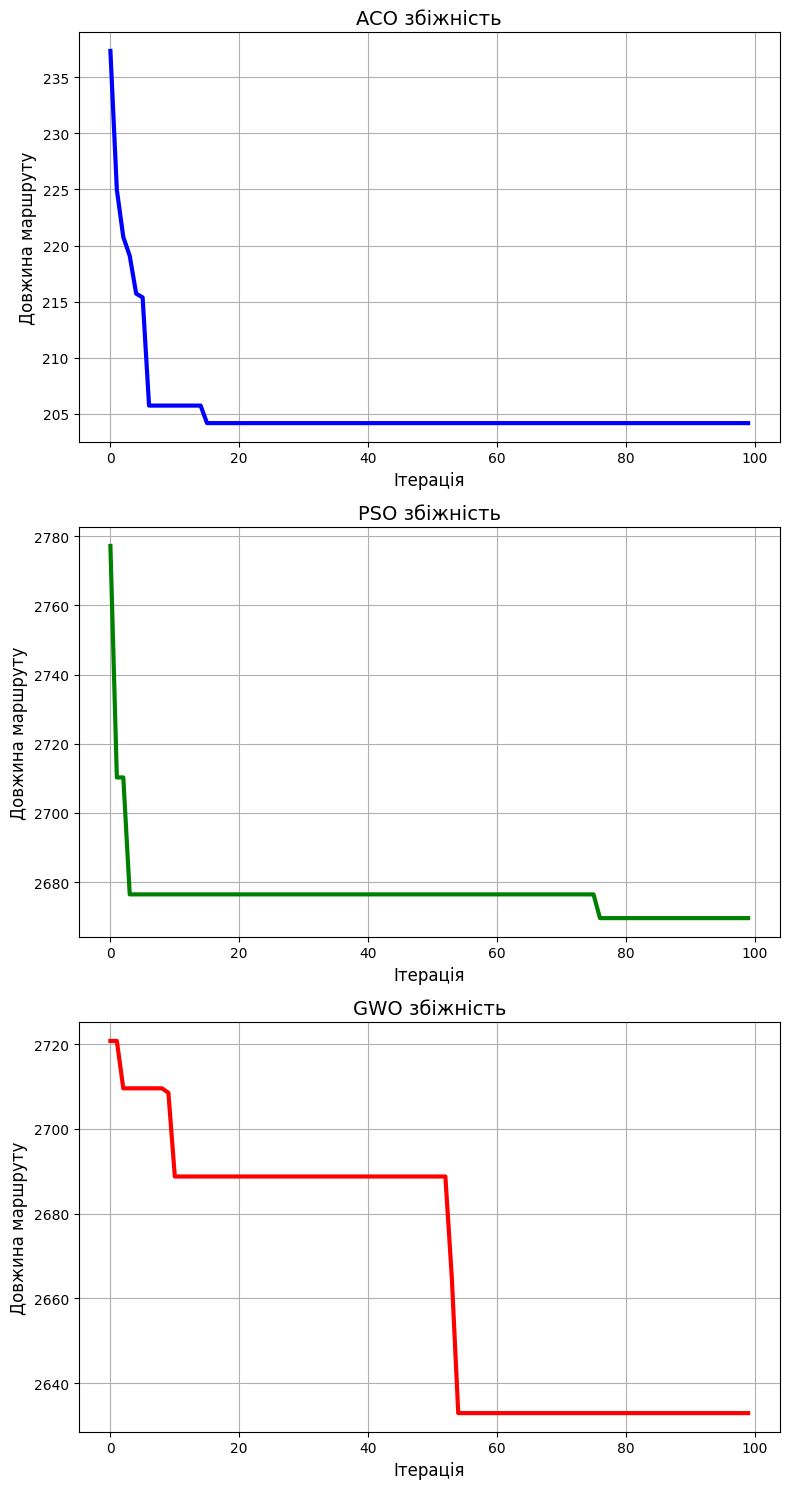

In [ ]:
colors = ["blue", "green", "red"]

fig, axes = plt.subplots(3, 1, figsize=(8, 15))

for i, r in enumerate(results):
    axes[i].plot(
        r["history"],
        color=colors[i],
        linewidth=3
    )

    axes[i].set_title(f'{r["algorithm"]} збіжність', fontsize=14)
    axes[i].set_xlabel("Ітерація", fontsize=12)
    axes[i].set_ylabel("Довжина маршруту", fontsize=12)

    axes[i].grid(True)

plt.tight_layout()
plt.show()

### 4.2 Експеременти
- Для зменшення обчислювальної складності задачі використовується лише перша половина міст із початкового датасету.

In [34]:
ukraine_half = ukraine_df.iloc[:len(ukraine_df) // 2]
cities = ukraine_half["city"].values

dim = len(cities)

coords_half = ukraine_half[["x", "y"]].values

dist_matrix = cdist(coords_half, coords_half, metric='euclidean')

-  Виконання кожного алгоритму (ACO, PSO та GWO) по 5 незалежних запусків.

In [35]:
def experiments(method_name, n):
    
    lengths = []
    times = []

    for _ in range(n):

        start = time.perf_counter()

        if method_name == "ACO":
            path, length, _, _ = ant_algorithm(dist_matrix, generations, pop_size)

        elif method_name == "PSO":
            pos, length, _ =  pso(func, dim, pop_size, generations)
            path = np.argsort(pos)

        elif method_name == "GWO":
            pos, length, _, _ = gwo(func, pop_size, generations, dim)
            path = np.argsort(pos)

        end = time.perf_counter()

        lengths.append(length)
        times.append(end - start)

    return {
        "method": method_name, 
        "mean_length": np.mean(lengths),
        "std_length": np.std(lengths),
        "best_length": np.min(lengths),
        "worst_length": np.max(lengths),
        "mean_time": np.mean(times),
        "std_time": np.std(times),
    }

In [36]:
experiment_results = []

experiment_results.append(experiments("ACO", 5))
experiment_results.append(experiments("PSO", 5))
experiment_results.append(experiments("GWO", 5))

experiment_df = pd.DataFrame(experiment_results)

In [37]:
experiment_df = experiment_df.round(4)
print(experiment_df)

  method  mean_length  std_length  best_length  worst_length  mean_time  \
0    ACO     126.1895      1.1184     124.5734      127.8364   360.7031   
1    PSO    1245.1192     11.7608    1222.1478     1255.5794     1.7129   
2    GWO    1241.7997     27.5151    1207.5271     1276.2371     1.6110   

   std_time  
0    7.7814  
1    0.0236  
2    0.0574  


### 4.3 Графік середньої довжини маршруту

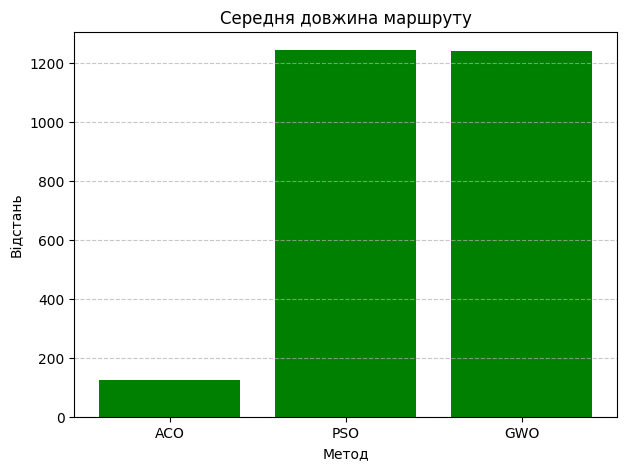

In [39]:
plt.figure(figsize=(7,5))

plt.bar(
    experiment_df["method"],
    experiment_df["mean_length"],
    color="green"
)

plt.title("Середня довжина маршруту")
plt.ylabel("Відстань")
plt.xlabel("Метод")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 4.4 Графік стабільності

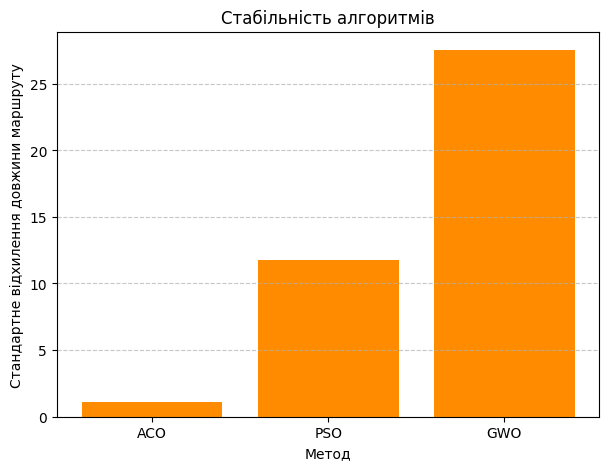

In [40]:
plt.figure(figsize=(7,5))

plt.bar(
    experiment_df["method"],
    experiment_df["std_length"],
    color="darkorange"
)

plt.title("Стабільність алгоритмів")
plt.ylabel("Стандартне відхилення довжини маршруту")
plt.xlabel("Метод")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()